<a href="https://colab.research.google.com/github/leticia1804/Trabalho_Pratico-_Estatistica_e_ProgramacaoR/blob/main/Trabalho_Pr%C3%A1tico_LeticiadosSantos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Trabalho Prático: Estatística e Probabilidade Aplicada à Astronomia
####Pós-Graduação em Ciência de Dados - UNICARIOCA

###**Calibração de Brilho em Estrelas Variáveis**

**Aluna:** Letícia de Barros dos Santos

**Professores Orientadores:**

-Sérgio Monteiro, D.Sc.

-Manuel Martins, D.Sc.

---




##**Introdução**

Este trabalho tem como objetivo aplicar conceitos de estatística e probabilidade em um contexto astronômico, simulando medições do brilho de uma estrela variável. Em astronomia, observações de brilho são frequentemente influenciadas por ruídos instrumentais e atmosféricos, fazendo com que as medições apresentem comportamento aproximado de uma Distribuição Normal (Gaussiana).

A proposta consiste em gerar 1.000 observações simuladas utilizando a linguagem R, realizar análises estatísticas descritivas, construir visualizações gráficas, calcular intervalos de confiança, executar testes de hipótese e identificar possíveis outliers presentes nos dados.

Todo o desenvolvimento foi realizado no Google Colab utilizando R.

---



#**Desenvolvimento do Código**

##**Configuração do Ambiente e Simulação dos Dados**

Inicialmente, configuramos o ambiente para execução e definimos uma semente aleatória para garantir a reprodução dos resultados.

Na etapa de simulação, foi utilizado o comando rnorm() para gerar 1.000 observações simuladas do brilho estelar.

Parâmetros utilizados:

* n = quantidade de observações;

* mean = brilho médio esperado da estrela;

* sd = desvio padrão associado ao ruído instrumental.


Como os dados seguem uma distribuição normal, espera-se que os valores fiquem concentrados próximos da média.

In [19]:
# ---------------------------
# Limpeza do ambiente
# ---------------------------
rm(list = ls())

# ---------------------------
# Definindo semente para reprodutibilidade
# ---------------------------
set.seed(42)

# ---------------------------
# Carregamento de bibliotecas
# ---------------------------
install.packages("ggplot2") # Instalando pacote
library(ggplot2) # Carregando biblioteca

install.packages("dplyr") #instalando dplyr para uso summarise()
library(dplyr) # carregando biblioteca

cat("=========================================================\n")
cat("ESTATÍSTICA E PROBABILIDADE APLICADA À ASTRONOMIA\n")
cat("Pós-Graduação em Ciência de Dados - UNICARIOCA\n")

cat("Trabalho Prático:\n")
cat("Calibração de Brilho em Estrelas Variáveis\n")
cat("=========================================================\n")

cat("Aluna: Letícia de Barros dos Santos\n")
cat("Professores Orientadores:\nSérgio Monteiro, D.Sc.\nManuel Martins, D.Sc.\n")
cat("=========================================================\n\n\n")

# -----------------------------------------------------
# Parâmetros da Simulação
# -----------------------------------------------------

n_observacoes <- 1000
media_teorica <- 15.5
desvio_padrao <- 0.8
nivel_confianca <- 0.95

cat("=====================================\n")
cat("Parâmetros da simulação\n")
cat("=====================================\n")
cat("nº de observações", n_observacoes, "\n")
cat("média teórica", media_teorica, "\n")
cat("desvio padrão", desvio_padrao, "\n")
cat("nível de confiança", nivel_confianca, "\n")

# -----------------------------------------------------
# Simulação dos Dados
# -----------------------------------------------------

#utilizando a função rnorm(), assumindo média de 15.5 magnitudes e desvio padrão de 0.8.
brilho_estelar <- rnorm(
  n = n_observacoes,
  mean = media_teorica,
  sd = desvio_padrao)

# Criação do dataframe
dados <- data.frame(
  observacao = 1:n_observacoes,
  brilho = brilho_estelar
)
cat("=====================================\n")
cat("Simulação dos dados\n")
cat("=====================================\n")

# Visualização dos dados
#print(dados) -   TODOS OS VETORES
head(dados) # VALORES INICIAIS


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



ESTATÍSTICA E PROBABILIDADE APLICADA À ASTRONOMIA
Pós-Graduação em Ciência de Dados - UNICARIOCA
Trabalho Prático:
Calibração de Brilho em Estrelas Variáveis
Aluna: Letícia de Barros dos Santos
Professores Orientadores:
Sérgio Monteiro, D.Sc.
Manuel Martins, D.Sc.


Parâmetros da simulação
nº de observações 1000 
média teórica 15.5 
desvio padrão 0.8 
nível de confiança 0.95 
Simulação dos dados


,observacao,brilho
,<int>,<dbl>
1,1,16.59677
2,2,15.04824
3,3,15.79050
4,4,16.00629
5,5,15.82341
6,6,15.41510


## **Estatística Descritiva**

A estatística descritiva permite resumir e compreender o comportamento das amostras observadas (dados simulados).

No contexto astronômico, essas medidas permitem analisar:

* a tendência central das medições de brilho;

* a variabilidade associada ao ruído instrumental;

* a dispersão das observações;

* a estabilidade estatística dos dados simulados.


**Foram calculadas:**

* média;
* mediana;
* desvio padrão;
* variância;
* alores mínimo e máximo;
* amplitude;
* resumo estatístico geral.


A análise descritiva permitiu caracterizar numericamente o comportamento das observações simuladas. Observamos proximidade entre média e mediana, indicando simetria da distribuição, além de uma dispersão compatível com o ruído instrumental definido no modelo.Esses resultados sugerem estabilidade estatística durante a simulação.

In [11]:
# =====================================================
# ESTATÍSTICA DESCRITIVA
# =====================================================

# Cálculo das principais métricas estatísticas

cat("=====================================\n")
cat("Métricas Estatísticas\n")
cat("=====================================\n")

# Média das observações simuladas.
media = mean(dados$brilho)
print(paste('media =', media))

# Mediana - Determina o valor central da distribuição.
mediana = median(dados$brilho)
print(paste('mediana =', mediana))

# Desvio padrão da amostra - mede o nível de dispersão dos dados em torno da média.
desvio_padrao = sd(dados$brilho)
print(paste('desvio_padrao =', desvio_padrao))

#variancia
variancia = var(dados$brilho)
print(paste('variancia =', variancia))

#valor máximo e mínimo
minimo = min(dados$brilho)
maximo = max(dados$brilho)
print(paste('minimo =', minimo))
print(paste('maximo =', maximo))

#amplitude
amplitude = max(dados$brilho) - min(dados$brilho)
print(paste('amplitude =', amplitude))

# Fornece um resumo estatístico geral
summary(dados$brilho)


Métricas Estatísticas
[1] "media = 15.479340458678"
[1] "mediana = 15.4894926578705"
[1] "desvio_padrao = 0.80201698946397"
[1] "variancia = 0.643231251388851"
[1] "minimo = 12.8026087339596"
[1] "maximo = 18.2962434111885"
[1] "amplitude = 5.49363467722889"


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  12.80   14.96   15.49   15.48   16.03   18.30 

##**Visualização Gráfica Explicação**
Para verificar visualmente a aderência dos dados à Distribuição Normal, foi construído um histograma sobreposto por uma curva de densidade teórica.

Foi utilizado o pacote ggplot2, amplamente empregado para visualização estatística em R.

O histograma apresenta formato semelhante ao de uma curva em sino, característica da Distribuição Normal. A curva vermelha representa a distribuição teórica ajustada aos dados observados.

Observa-se boa aderência entre os valores simulados e o comportamento esperado para distribuições gaussianas.

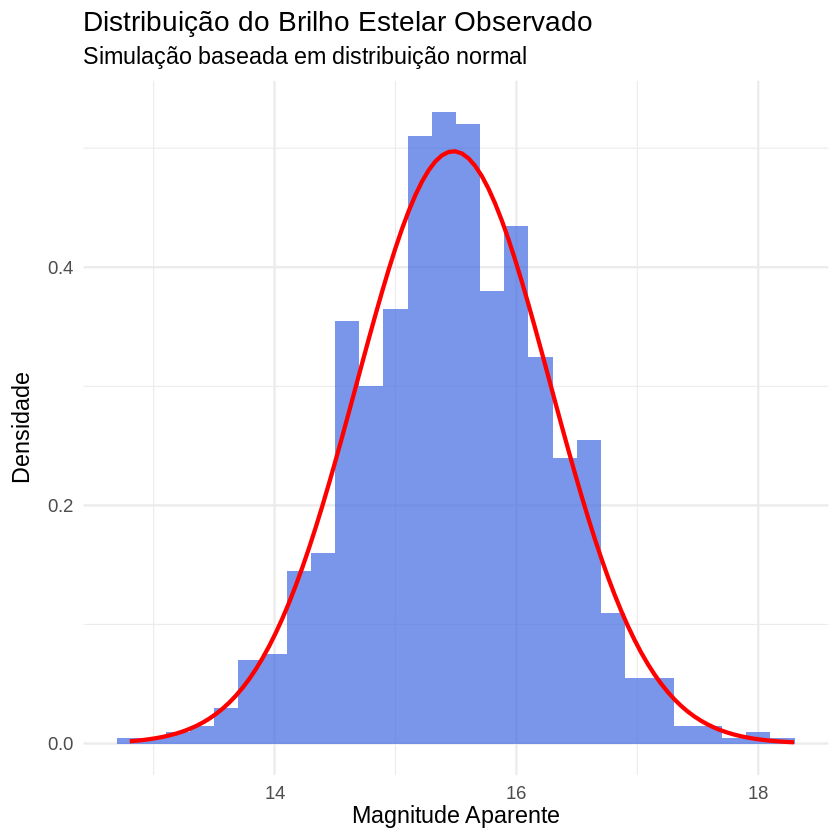

In [12]:
# =====================================================
# VISUALIZAÇÃO GRÁFICA
# HISTOGRAMA + CURVA NORMAL
# =====================================================

ggplot(dados, aes(x = brilho)) +

# construção do histograma
  geom_histogram(
    aes(y = after_stat(density)), #eixo vertical-densidade probabilística ao invés de frequência absoluta.
    binwidth = 0.2,
    fill = "royalblue",
    alpha = 0.7
  ) +

# Curva Normal
  stat_function( #Adiciona a curva de densidade normal teórica.
    fun = dnorm,
    args = list(
      mean = mean(dados$brilho),
      sd = sd(dados$brilho)
    ),
    color = "red",
    linewidth = 1.2
  ) +
# Tema gráfico - estilo visual acadêmico mais limpo
  theme_minimal(base_size = 14) +
# Títulos e legendas
  labs(
    title = "Distribuição do Brilho Estelar Observado",
    subtitle = "Simulação baseada em distribuição normal",
    x = "Magnitude Aparente",
    y = "Densidade"
  )


##**Intervalo de Confiança (95%)**


O intervalo de confiança permite estimar uma faixa de valores na qual provavelmente se encontra a verdadeira média populacional.

Foi utilizado um nível de confiança de 95%.

O intervalo encontrado representa os possíveis valores da média real do brilho da estrela considerando um nível de confiança de 95%.

Como a média utilizada na simulação está contida no intervalo, os resultados demonstram consistência estatística.


In [13]:
# =====================================================
# INTERVALO DE CONFIANÇA (95%)
# =====================================================

# Média amostral
media_amostral <- mean(dados$brilho)

# Erro padrão da média
erro_padrao <- sd(dados$brilho) /
  sqrt(n_observacoes)

# Intervalo de confiança para 95%
#z_critico <- qnorm(0.975)

# Limites do intervalo - 1.96(valor crítico da distribuição normal para um nível de confiança de 95%.)
ic_inferior <- media_amostral -
 1.96 * erro_padrao

ic_superior <- media_amostral +
  1.96 * erro_padrao

# Exibição dos resultados
cat("\n=====================================\n")
cat("INTERVALO DE CONFIANÇA (95%)\n")
cat("=====================================\n")

cat("Média Amostral:", media_amostral, "\n")
cat("Erro Padrão:", erro_padrao, "\n")
cat("Limite Inferior:", ic_inferior, "\n")
cat("Limite Superior:", ic_superior, "\n")



INTERVALO DE CONFIANÇA (95%)
Média Amostral: 15.47934 
Erro Padrão: 0.025362 
Limite Inferior: 15.42963 
Limite Superior: 15.52905 


##**Teste de Hipótese**

O teste de hipótese foi utilizado para verificar se a média observada difere significativamente do valor teórico esperado.

Hipóteses
* H0: μ = 15.5
* H1: μ ≠ 15.5

Foi aplicado o t teste.
A análise do valor-p (p-value) permite avaliar a hipótese nula.

* Se p-value < 0.05: rejeita-se H0;

* Se p-value > 0.05: não há evidências suficientes para rejeitar H0.

Como os dados foram simulados próximos da média teórica, espera-se que o teste indique compatibilidade entre a média amostral e o valor esperado.

In [18]:
# =====================================================
# TESTE DE HIPÓTESE
# =====================================================

# Aplicação do teste t de Student
resultado_teste <- t.test(

  dados$brilho,

  mu = media_teorica, #Define o valor populacional utilizado como referência.

  conf.level = nivel_confianca

)

# Exibição dos resultados
cat("=====================================\n")
cat("TESTE DE HIPÓTESE\n")
cat("=====================================\n")

print(resultado_teste)


TESTE DE HIPÓTESE

	One Sample t-test

data:  dados$brilho
t = -0.81459, df = 999, p-value = 0.4155
alternative hypothesis: true mean is not equal to 15.5
95 percent confidence interval:
 15.42957 15.52911
sample estimates:
mean of x 
 15.47934 



##**Diagnóstico de Outliers**

Outliers são observações discrepantes que apresentam afastamento significativo em relação ao comportamento predominante do conjunto de dados.

Em contextos astronômicos, essas observações podem estar associadas a:

falhas instrumentais;
ruídos atmosféricos;
erros de captura;
interferências externas.

Neste trabalho, os outliers foram identificados utilizando o método do Intervalo Interquartil (IQR).

Os pontos destacados fora da caixa representam possíveis valores atípicos.
Os outliers identificados representam medições incomuns que podem impactar análises estatísticas futuras como média,variância e desvio padrão.

A presença dessas observações demonstra a importância de métodos de limpeza e validação de dados em projetos de ciência de dados.

DIAGNÓSTICO DE OUTLIERS
Limite Inferior: 13.35227 
Limite Superior: 17.63856 
Quantidade de Outliers: 11 
   observacao   brilho
1          59 13.10553
2         118 17.66151
3         269 13.34006
4         459 17.87269
5         525 18.08326
6         647 13.08565
7         820 18.06896
8         900 17.68176
9         906 13.13298
10        980 12.80261
11        988 18.29624


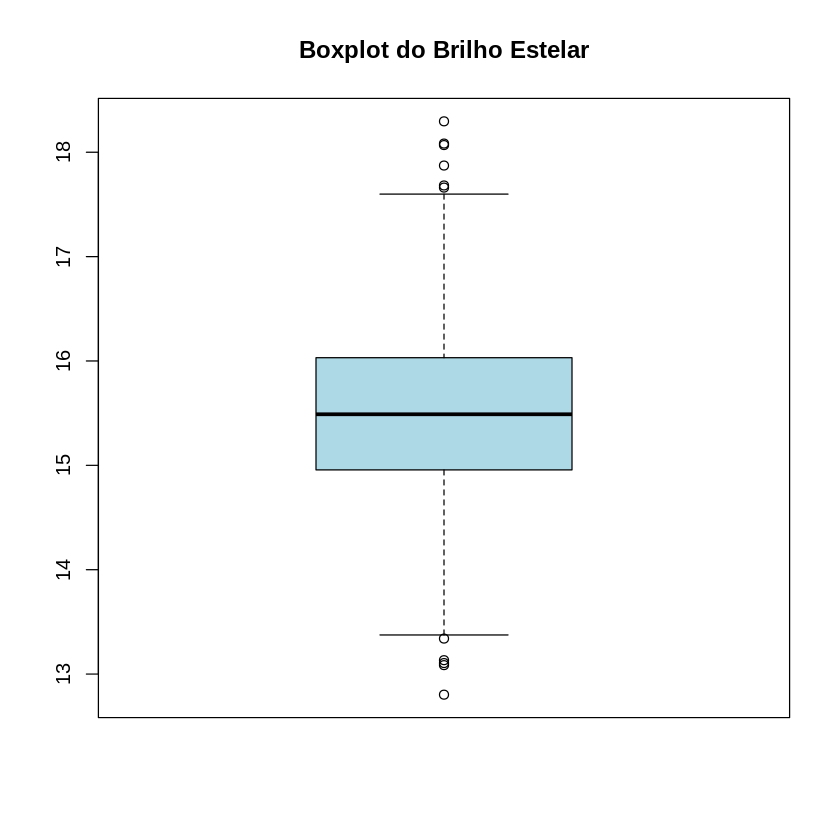

In [15]:
# =====================================================
# DETECÇÃO DE OUTLIERS
# =====================================================

boxplot(
  brilho_estelar,
  main = "Boxplot do Brilho Estelar",
  col = "lightblue"
)

# Cálculo dos quartis
Q1 <- quantile(dados$brilho, 0.25)

Q3 <- quantile(dados$brilho, 0.75)

# Intervalo interquartil
IQR_valor <- IQR(dados$brilho)

# Limites inferior e superior
limite_inferior <- Q1 -
  1.5 * IQR_valor

limite_superior <- Q3 +
  1.5 * IQR_valor

# Identificação dos outliers
outliers <- dados %>%

  filter(

    brilho < limite_inferior |

    brilho > limite_superior

  )

# Exibição dos resultados
cat("=====================================\n")
cat("DIAGNÓSTICO DE OUTLIERS\n")
cat("=====================================\n")

cat("Limite Inferior:",
    limite_inferior, "\n")

cat("Limite Superior:",
    limite_superior, "\n")

cat("Quantidade de Outliers:",
    nrow(outliers), "\n")

# Visualização dos outliers
print(outliers)

## **Conclusão**
O presente trabalho possibilitou a aplicação prática de conceitos fundamentais de estatística e probabilidade em um contexto astronômico.

A simulação das medições de brilho estelar apresentou comportamento compatível com a Distribuição Normal, demonstrando aderência ao modelo teórico esperado.

As análises descritivas permitiram compreender a dispersão dos dados, enquanto o intervalo de confiança e o teste de hipótese confirmaram a coerência entre a média observada e o valor populacional definido.

Além disso, a identificação de outliers evidenciou a importância do tratamento de dados discrepantes em aplicações científicas e instrumentais.

Dessa forma, o projeto demonstrou como técnicas estatísticas podem ser utilizadas para auxiliar na interpretação e validação de observações astronômicas.